PROJECT : BLACK FRIDAY SALES DATA ANALYSIS

>>>This project analyzes Black Friday sales data to understand customer purchasing behavior and shopping trends. It explores key factors such as age, gender, occupation, product categories, and purchase amounts. Through comprehensive Exploratory Data Analysis (EDA), we identify buying patterns, compare customer segments, and visualize sales distributions.
The insights gained will help businesses improve marketing strategies, understand customer preferences, and increase sales during major shopping events.

IMPORT REQUIRE LIBRARIES AND LOAD THE DATASET

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
df=pd.read_csv("BlackFriday.csv")

In [2]:
#To check first 5 rows
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 537577 entries, 0 to 537576
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     537577 non-null  int64  
 1   Product_ID                  537577 non-null  object 
 2   Gender                      537577 non-null  object 
 3   Age                         537577 non-null  object 
 4   Occupation                  537577 non-null  int64  
 5   City_Category               537577 non-null  object 
 6   Stay_In_Current_City_Years  537577 non-null  object 
 7   Marital_Status              537577 non-null  int64  
 8   Product_Category_1          537577 non-null  int64  
 9   Product_Category_2          370591 non-null  float64
 10  Product_Category_3          164278 non-null  float64
 11  Purchase                    537577 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 49.2+ MB


In [4]:
df.isnull().sum()

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            166986
Product_Category_3            373299
Purchase                           0
dtype: int64

In [5]:
df.dropna()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
6,1000004,P00184942,M,46-50,7,B,2,1,1,8.0,17.0,19215
13,1000005,P00145042,M,26-35,20,A,1,1,1,2.0,5.0,15665
14,1000006,P00231342,F,51-55,9,A,1,0,5,8.0,14.0,5378
16,1000006,P0096642,F,51-55,9,A,1,0,2,3.0,4.0,13055
...,...,...,...,...,...,...,...,...,...,...,...,...
537549,1004734,P00345842,M,51-55,1,B,1,1,2,8.0,14.0,13082
537551,1004735,P00313442,M,46-50,3,C,3,0,5,6.0,8.0,6863
537562,1004736,P00146742,M,18-25,20,A,1,1,1,13.0,14.0,11508
537571,1004737,P00221442,M,36-45,16,C,1,0,1,2.0,5.0,11852


In [6]:
df.columns

Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1',
       'Product_Category_2', 'Product_Category_3', 'Purchase'],
      dtype='object')

In [7]:
del df["Product_Category_2"]
del df["Product_Category_3"]
df

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969
...,...,...,...,...,...,...,...,...,...,...
537572,1004737,P00193542,M,36-45,16,C,1,0,1,11664
537573,1004737,P00111142,M,36-45,16,C,1,0,1,19196
537574,1004737,P00345942,M,36-45,16,C,1,0,8,8043
537575,1004737,P00285842,M,36-45,16,C,1,0,5,7172


In [8]:
df["User_ID"].nunique()

5891

In [9]:
df["Product_ID"].nunique()

3623

In [10]:
df["Gender"].unique()

array(['F', 'M'], dtype=object)

In [11]:
df["Occupation"].nunique()

21

In [12]:
df["Marital_Status"].nunique()

2

In [13]:
df["City_Category"].unique()

array(['A', 'C', 'B'], dtype=object)

In [14]:
df["Stay_In_Current_City_Years"].unique()

array(['2', '4+', '3', '1', '0'], dtype=object)

In [15]:
df["Marital_Status"].unique()

array([0, 1])

In [16]:
df["Product_Category_1"].unique()

array([ 3,  1, 12,  8,  5,  4,  2,  6, 14, 11, 13, 15,  7, 16, 18, 10, 17,
        9])

In [20]:
df["Purchase"].sum()
df["Purchase"].sum()/len(df["Purchase"])

np.float64(9333.859852635065)

In [21]:
for column in df.columns:
    print(column ,df[column].nunique())

User_ID 5891
Product_ID 3623
Gender 2
Age 7
Occupation 21
City_Category 3
Stay_In_Current_City_Years 5
Marital_Status 2
Product_Category_1 18
Purchase 17959


In [22]:
df["Gender"]

0         F
1         F
2         F
3         F
4         M
         ..
537572    M
537573    M
537574    M
537575    M
537576    M
Name: Gender, Length: 537577, dtype: object

In [23]:
df[df["Gender"]=="M"]

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Purchase
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969
5,1000003,P00193542,M,26-35,15,A,3,0,1,15227
6,1000004,P00184942,M,46-50,7,B,2,1,1,19215
7,1000004,P00346142,M,46-50,7,B,2,1,1,15854
8,1000004,P0097242,M,46-50,7,B,2,1,1,15686
...,...,...,...,...,...,...,...,...,...,...
537572,1004737,P00193542,M,36-45,16,C,1,0,1,11664
537573,1004737,P00111142,M,36-45,16,C,1,0,1,19196
537574,1004737,P00345942,M,36-45,16,C,1,0,8,8043
537575,1004737,P00285842,M,36-45,16,C,1,0,5,7172


In [24]:
df[df["Gender"]=="F"]

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
14,1000006,P00231342,F,51-55,9,A,1,0,5,5378
...,...,...,...,...,...,...,...,...,...,...
537472,1004726,P00037142,F,36-45,16,C,2,1,1,11845
537473,1004726,P00058442,F,36-45,16,C,2,1,5,5155
537474,1004726,P00303242,F,36-45,16,C,2,1,5,8626
537475,1004727,P00295942,F,55+,0,C,3,0,2,12826


In [25]:
len(df[df["Gender"]=="M"]),len(df[df["Gender"]=="F"])

(405380, 132197)

In [26]:
data=pd.DataFrame({"ratio":[len(df[df["Gender"]=="M"]),len(df[df["Gender"]=="F"])]},index=["Male","Female"])
data

,ratio
Male,405380
Female,132197


<Axes: ylabel='ratio'>

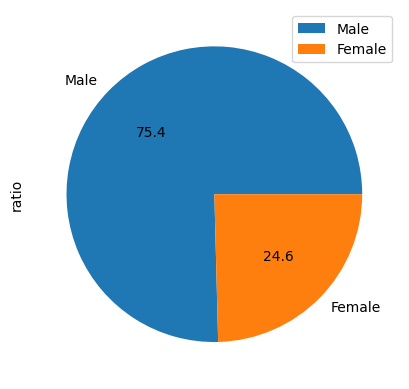

In [27]:
data.plot(kind="pie",y="ratio",autopct="%.1f")

<Axes: xlabel='Gender'>

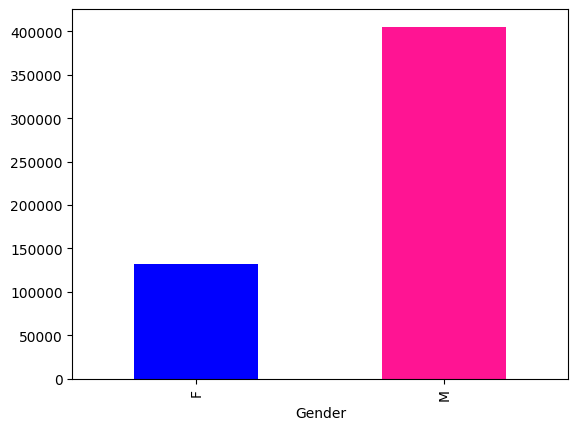

In [31]:
df.groupby("Gender").size().plot(kind="bar",color=["blue","deeppink"])

<Axes: >

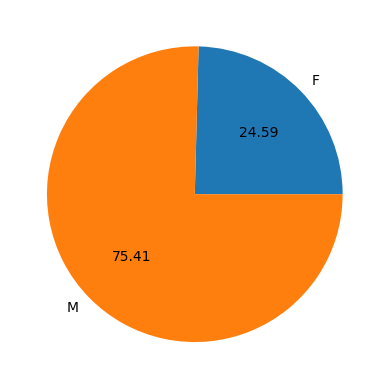

In [32]:
df.groupby("Gender").size().plot(kind="pie",autopct="%.2f")

In [33]:
df.groupby("Gender")["Purchase"].sum()

Gender
F    1164624021
M    3853044357
Name: Purchase, dtype: int64

<Axes: ylabel='Purchase'>

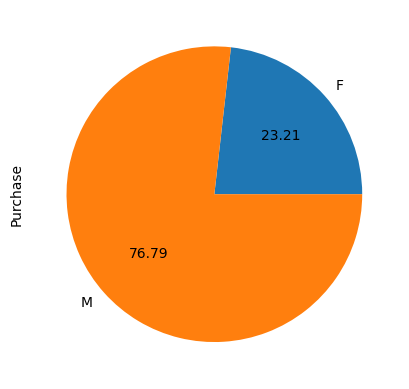

In [35]:
df.groupby("Gender")["Purchase"].sum().plot(kind="pie",autopct="%.2f")

In [36]:
df.groupby("Gender")["Purchase"].mean()

Gender
F    8809.761349
M    9504.771713
Name: Purchase, dtype: float64

<Axes: ylabel='Purchase'>

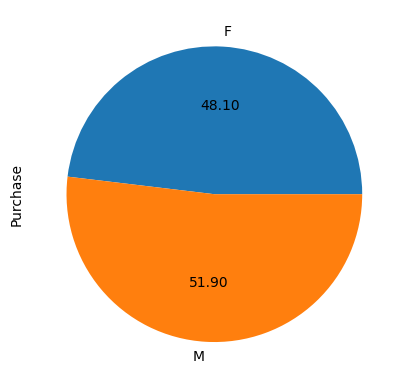

In [37]:
df.groupby("Gender")["Purchase"].mean().plot(kind="pie",autopct="%.2f")

In [38]:
df.groupby("Age").size()

Age
0-17      14707
18-25     97634
26-35    214690
36-45    107499
46-50     44526
51-55     37618
55+       20903
dtype: int64

<Axes: xlabel='Age'>

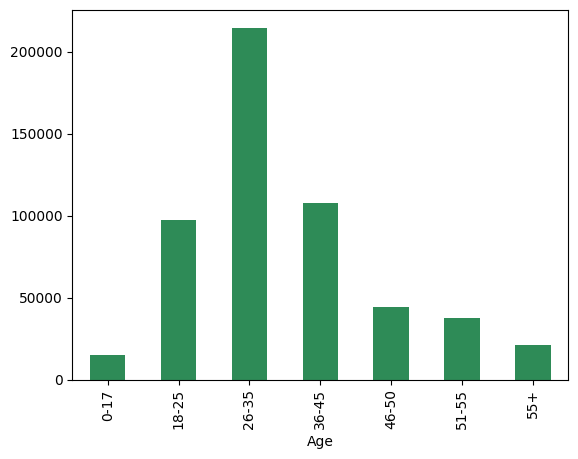

In [39]:
df.groupby("Age").size().plot(kind="bar",color="seagreen")

In [40]:
for i in df["Age"].unique():
    print(i)

0-17
55+
26-35
46-50
51-55
36-45
18-25


In [41]:
df[df["Age"]=="0-17"]

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
85,1000019,P00112542,M,0-17,10,A,3,0,1,7746
...,...,...,...,...,...,...,...,...,...,...
537280,1004690,P00242742,F,0-17,10,C,3,0,1,11561
537281,1004690,P00226442,F,0-17,10,C,3,0,11,6010
537282,1004690,P00181442,F,0-17,10,C,3,0,11,7458
537283,1004690,P00192042,F,0-17,10,C,3,0,5,3706


In [42]:
len(df[df["Age"]=="26-35"])

214690

In [43]:
for i in df["Age"].unique():
    print(i,":", len(df[df["Age"]==i]))

0-17 : 14707
55+ : 20903
26-35 : 214690
46-50 : 44526
51-55 : 37618
36-45 : 107499
18-25 : 97634


In [44]:
df[df["Age"]==i]

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Purchase
70,1000018,P00366542,F,18-25,3,B,3,0,5,1780
71,1000018,P00190742,F,18-25,3,B,3,0,3,10754
72,1000018,P00151842,F,18-25,3,B,3,0,4,2802
73,1000018,P00112642,F,18-25,3,B,3,0,1,19473
74,1000018,P00118442,F,18-25,3,B,3,0,1,19672
...,...,...,...,...,...,...,...,...,...,...
537566,1004736,P00048742,M,18-25,20,A,1,1,5,5350
537567,1004736,P00157542,M,18-25,20,A,1,1,8,1994
537568,1004736,P00250642,M,18-25,20,A,1,1,11,5930
537569,1004736,P00023142,M,18-25,20,A,1,1,5,7042


In [45]:
df[df["Age"]==i]["Product_ID"]

70        P00366542
71        P00190742
72        P00151842
73        P00112642
74        P00118442
            ...    
537566    P00048742
537567    P00157542
537568    P00250642
537569    P00023142
537570    P00162442
Name: Product_ID, Length: 97634, dtype: object

In [47]:
lst=[]
for i in df["Age"].unique():
    lst.append([i,df[df["Age"]==i]["Product_ID"].nunique()])
data=pd.DataFrame(lst,columns=["Age","Products"])    
data

,Age,Products
0,0-17,2300
1,55+,2573
2,26-35,3419
3,46-50,3099
4,51-55,2877
5,36-45,3318
6,18-25,3213


<Axes: xlabel='Age', ylabel='Product_ID'>

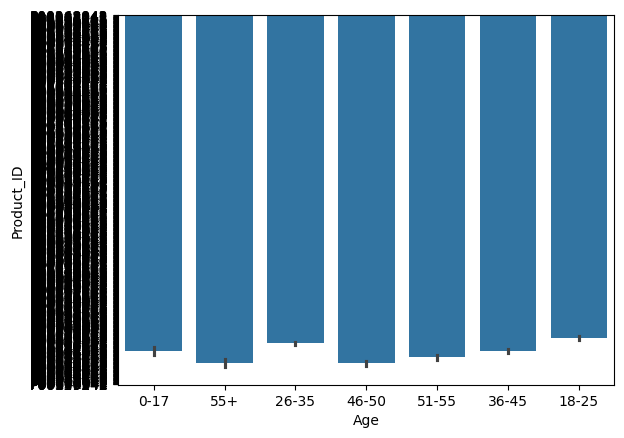

In [48]:
sns.barplot(x="Age",y="Product_ID",data=df)

BAR GRAPH OF AGE WITH HUE GENDER :

<Axes: xlabel='Age', ylabel='count'>

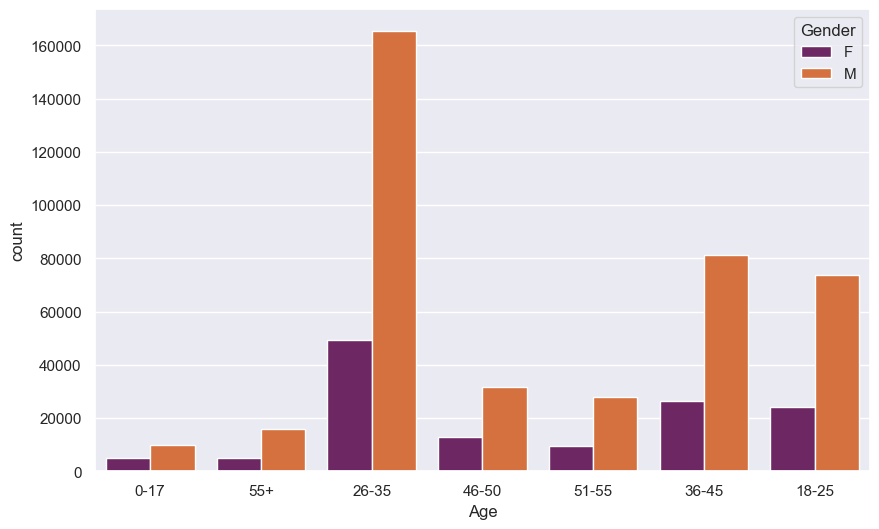

In [49]:
sns.set(rc={'figure.figsize':(10,6)})
sns.countplot(x="Age",hue="Gender",palette="inferno",data=df)

<Axes: xlabel='Gender', ylabel='count'>

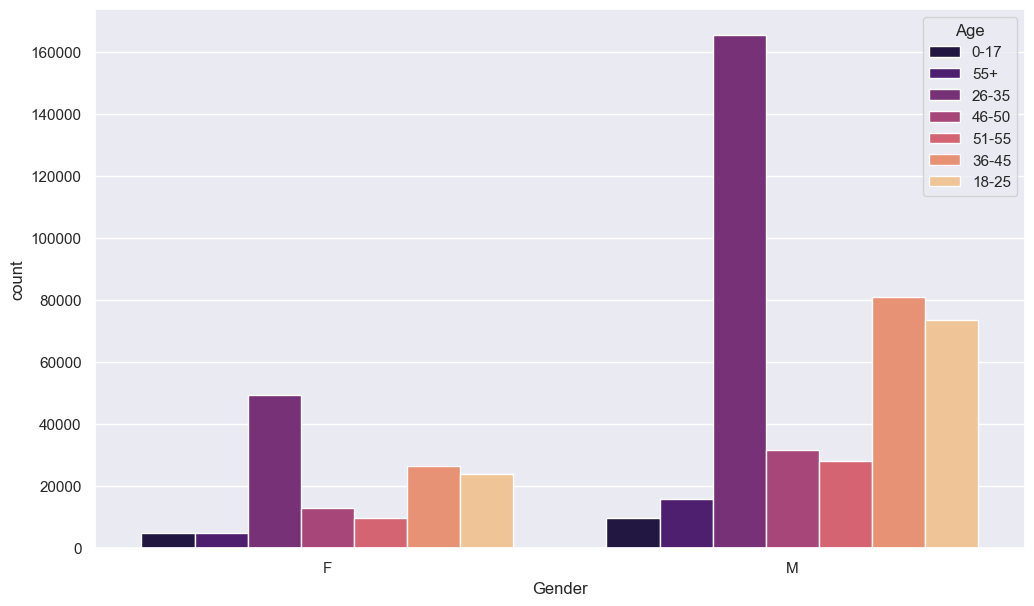

In [50]:
#COUNT PLOT OF GENDER WITH HUE AGE:
sns.set(rc={"figure.figsize":(12,7)})
sns.countplot(x="Gender",hue="Age",palette="magma",data=df)

COUNT PLOT OF GENDER WITH HUE MARITAL STATUS :

<Axes: xlabel='Gender', ylabel='count'>

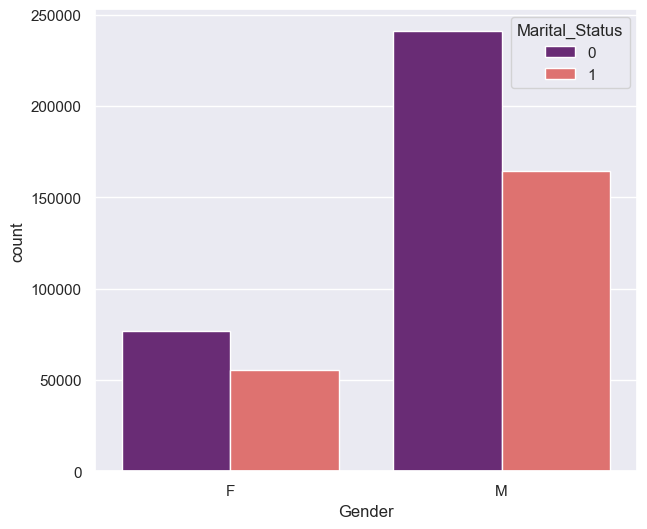

In [51]:
sns.set(rc={"figure.figsize":(7,6)})
sns.countplot(x="Gender",hue="Marital_Status",palette="magma",data=df)

<Axes: xlabel='Marital_Status', ylabel='count'>

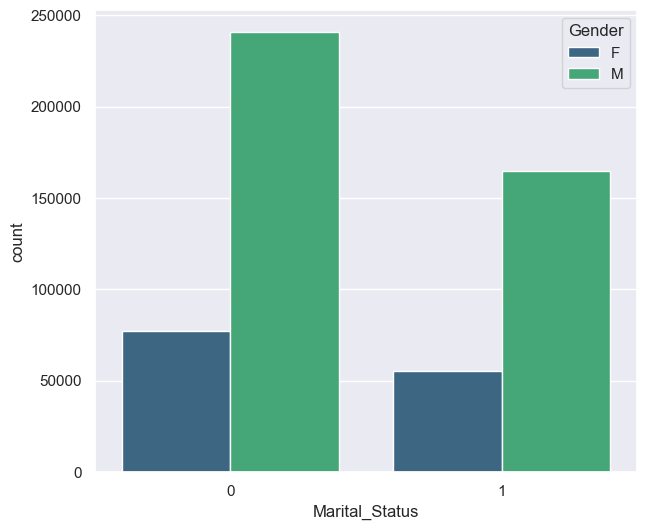

In [53]:
#Countplot of Marital_Status with hue Gender
sns.countplot(x="Marital_Status",hue="Gender",palette="viridis",data=df)

<Axes: xlabel='City_Category', ylabel='count'>

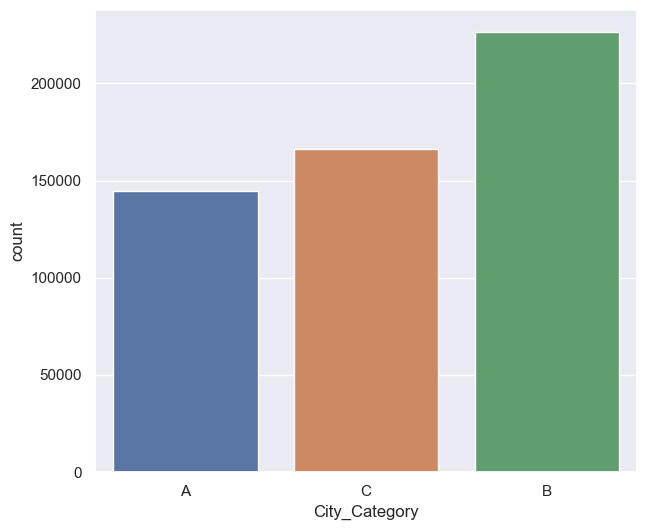

In [54]:
#Countplot of City_Category with hue City_Category
sns.countplot(x="City_Category",hue="City_Category",data=df)

COUNT PLOT OF CITY CATEGORY WITH HUE AGE :

<Axes: xlabel='City_Category', ylabel='count'>

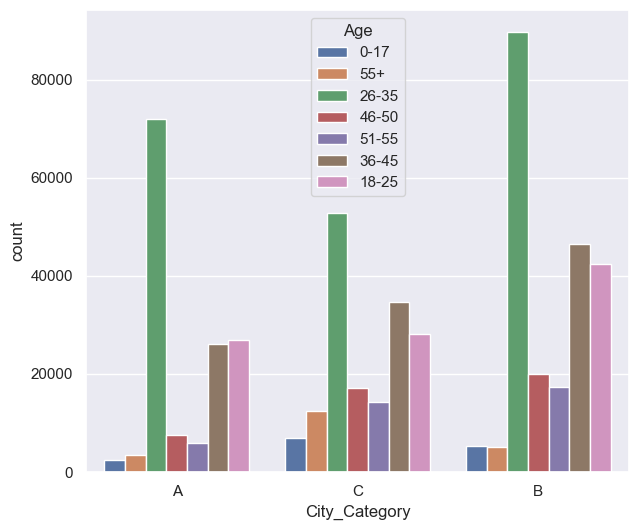

In [55]:
sns.countplot(x="City_Category",hue="Age",data=df)

COUNT PLOT OF AGE WITH HUE CITY CATEGORY :

<Axes: xlabel='Age', ylabel='count'>

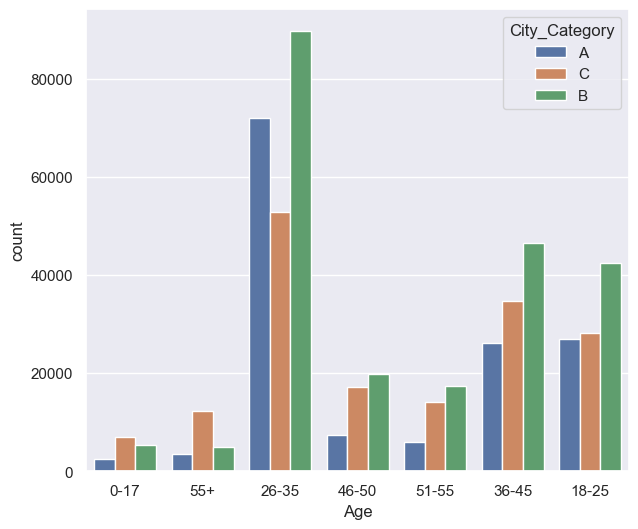

In [56]:
sns.countplot(x="Age",hue="City_Category",data=df)

COUNT PLOT OF MARITAL STATUS WITH HUE CITY CATEGORY:

<Axes: xlabel='Marital_Status', ylabel='count'>

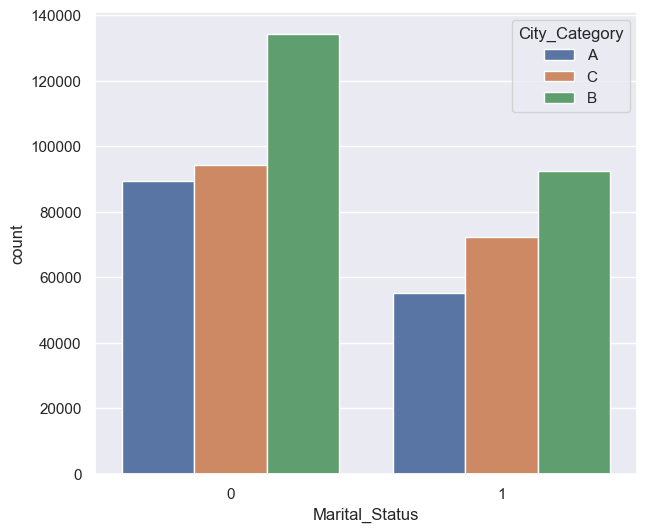

In [54]:
sns.countplot(x="Marital_Status",hue="City_Category",data=df)

<Axes: >

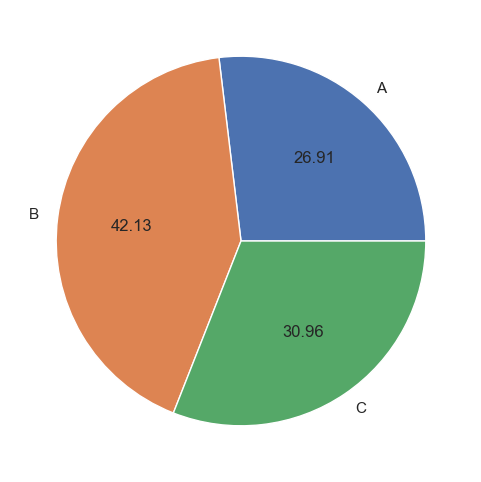

In [57]:
df.groupby("City_Category").size().plot(kind="pie",autopct="%.2f")

<Axes: xlabel='City_Category', ylabel='count'>

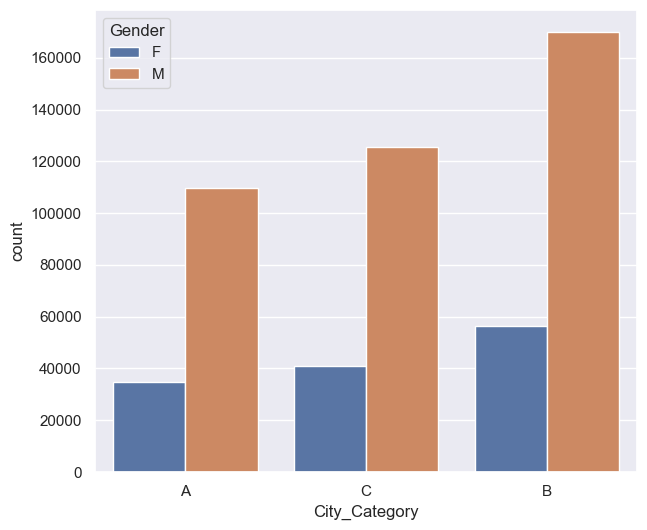

In [58]:
sns.countplot(x="City_Category",hue="Gender",palette="deep",data=df)

<Axes: xlabel='City_Category'>

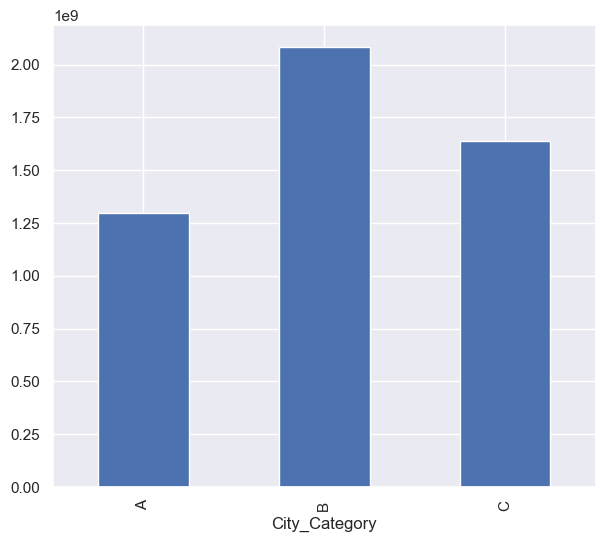

In [61]:
df.groupby("City_Category")["Purchase"].sum().plot(kind="bar")

WHICH CITY CATEGORY CONTRIBUTE MOST TOTAL PURCHASE ?

<Axes: ylabel='Purchase'>

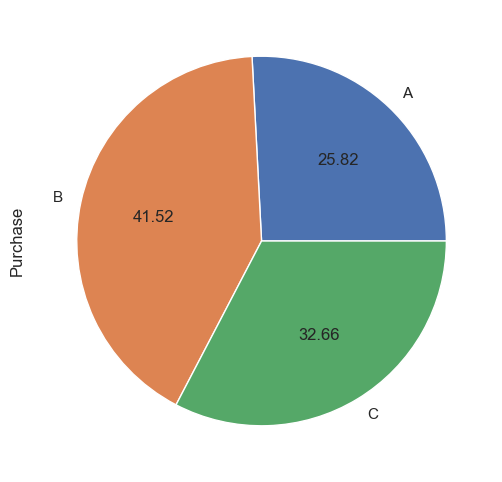

In [59]:
df.groupby("City_Category")["Purchase"].sum().plot(kind="pie",autopct="%.2f")

<Axes: ylabel='Purchase'>

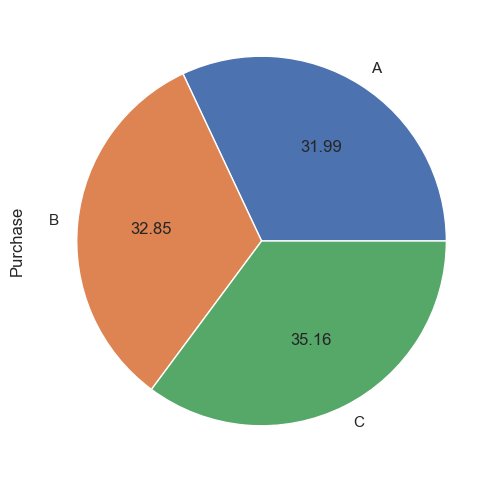

In [60]:
df.groupby("City_Category")["Purchase"].mean().plot(kind="pie",autopct="%.2f")

BAR GRAPH OF STAY IN CURRENT CITY:

C:\Users\somaa\AppData\Local\Temp\ipykernel_11972\580374827.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Stay_In_Current_City_Years",palette="bright",data=df)


<Axes: xlabel='Stay_In_Current_City_Years', ylabel='count'>

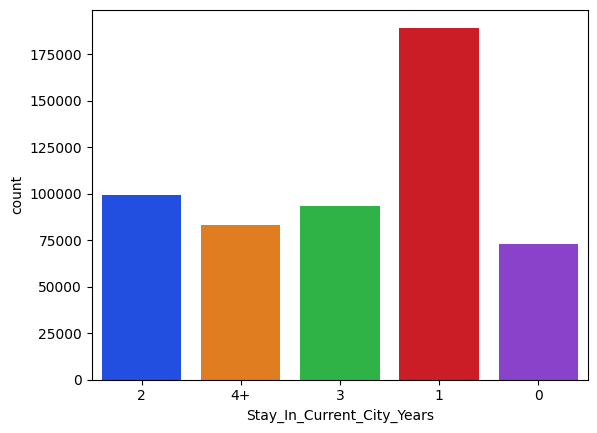

In [5]:
#stay in current city countplot
sns.countplot(x="Stay_In_Current_City_Years",palette="bright",data=df)

<Axes: >

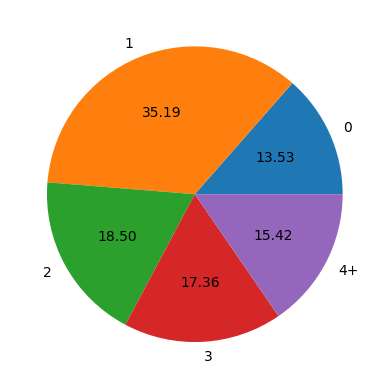

In [ ]:
#pie chart of stay in current city
df.groupby("Stay_In_Current_City_Years").size().plot(kind="pie",autopct="%.2f")

<Axes: xlabel='Stay_In_Current_City_Years'>

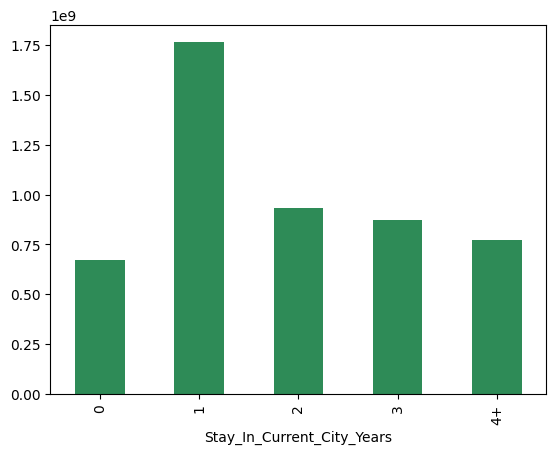

In [9]:
#sum groupby bar of stay in current city and purchase
df.groupby("Stay_In_Current_City_Years")["Purchase"].sum().plot(kind="bar",color="seagreen")

<Axes: xlabel='Stay_In_Current_City_Years'>

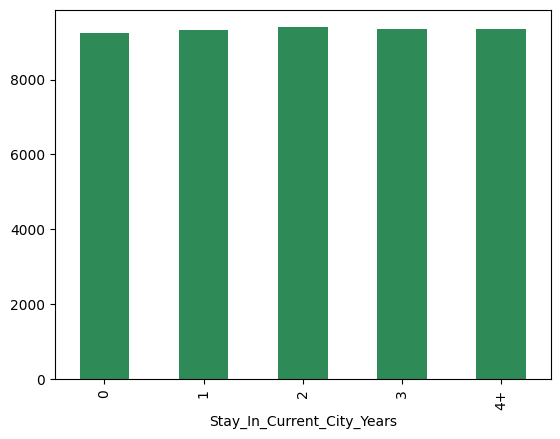

In [11]:
#mean groupby bar of stay in current city and purchase
df.groupby("Stay_In_Current_City_Years")["Purchase"].mean().plot(kind="bar",color="seagreen")

<Axes: xlabel='Stay_In_Current_City_Years', ylabel='count'>

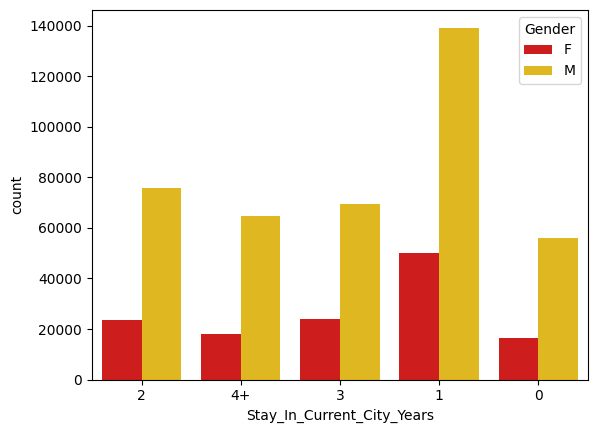

In [ ]:
#COUNT PLOT OF STAY IN CURRENT CITY WITH HUE GENDER :
sns.countplot(x="Stay_In_Current_City_Years",hue="Gender",palette="hot",data=df)

<Axes: xlabel='Stay_In_Current_City_Years', ylabel='count'>

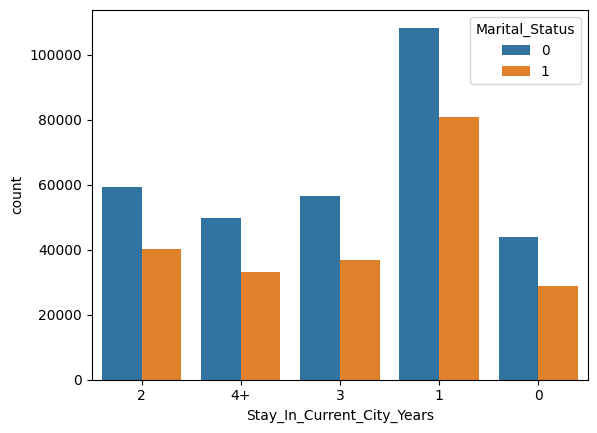

In [ ]:
#COUNT PLOT OF STAY IN CURRENT CITY WITH HUE MARITAL STATUS
sns.countplot(x="Stay_In_Current_City_Years",hue="Marital_Status",data=df)

<Axes: xlabel='Stay_In_Current_City_Years', ylabel='count'>

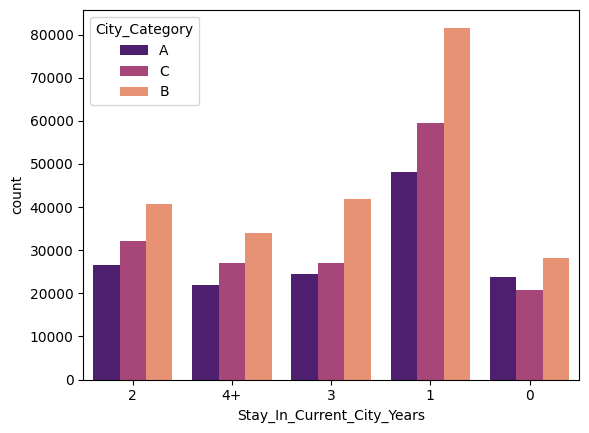

In [ ]:
#COUNT PLOT OF STAY IN CURRENT CITY WITH HUE CITY CATEGORY:
sns.countplot(x="Stay_In_Current_City_Years",hue="City_Category",palette="magma",data=df)

<Axes: xlabel='Stay_In_Current_City_Years'>

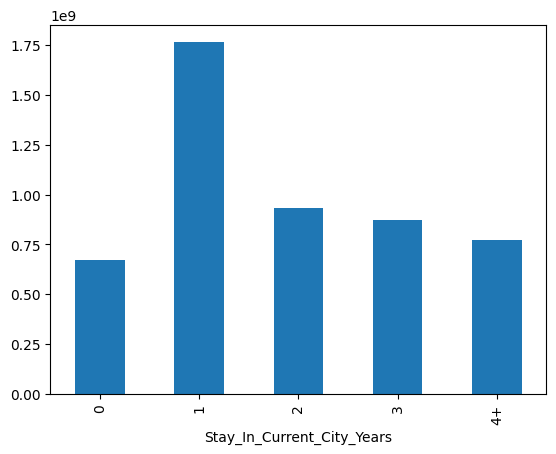

In [24]:
df.groupby("Stay_In_Current_City_Years")["Purchase"].sum().plot(kind="bar")

<Axes: xlabel='Stay_In_Current_City_Years'>

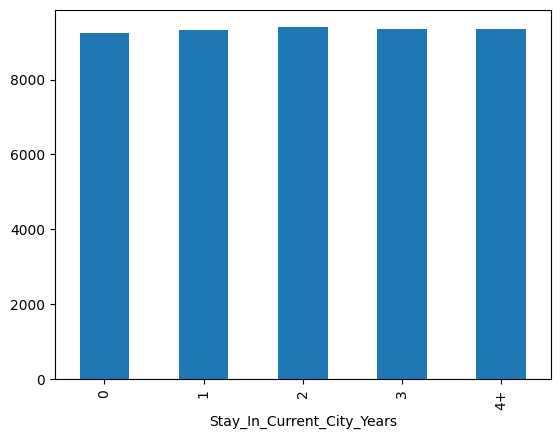

In [25]:
df.groupby("Stay_In_Current_City_Years")["Purchase"].mean().plot(kind="bar")

<Axes: xlabel='City_Category', ylabel='count'>

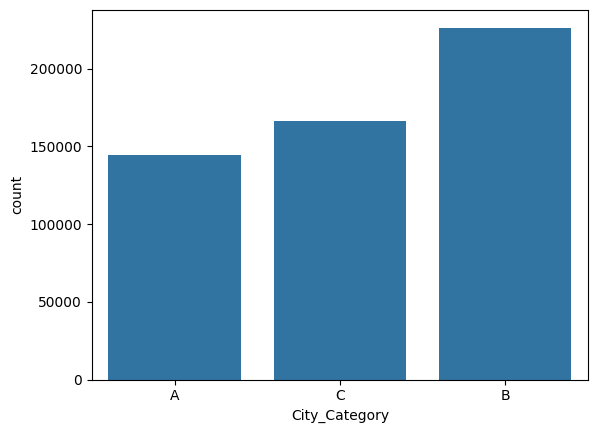

In [15]:
#count plot of city category
sns.countplot(x="City_Category",data=df)

<Axes: xlabel='City_Category', ylabel='count'>

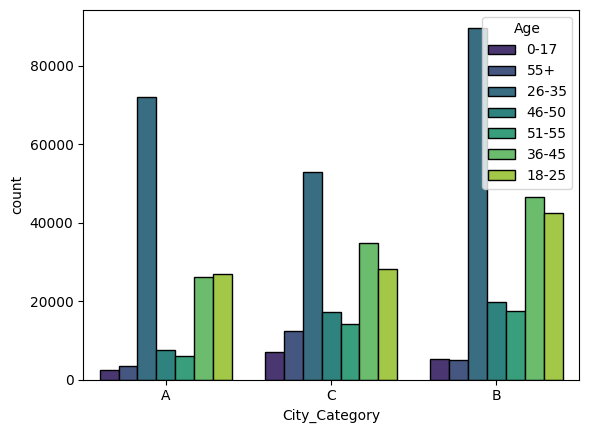

In [ ]:
#COUNT PLOT OF CITY CATEGORY WITH HUE AGE :
sns.countplot(x="City_Category",hue="Age",edgecolor="black",palette="viridis",data=df)

<Axes: xlabel='Occupation', ylabel='count'>

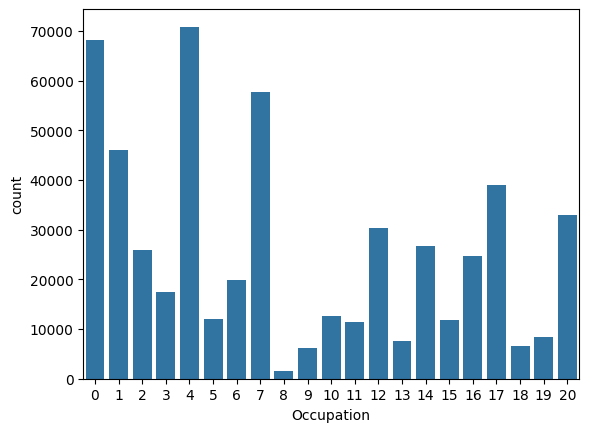

In [18]:
#count of occupation
sns.countplot(x="Occupation",data=df)

<Axes: xlabel='Occupation'>

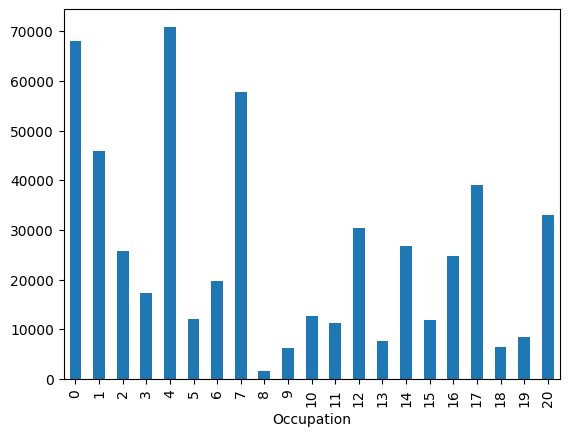

In [20]:
#occupation size)
df.groupby("Occupation").size().plot(kind="bar")

<Axes: xlabel='Occupation'>

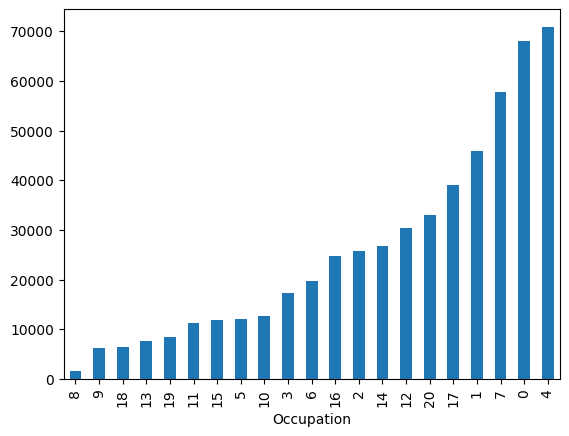

In [28]:
df.groupby("Occupation").size().sort_values().plot(kind="bar")

<Axes: xlabel='Occupation'>

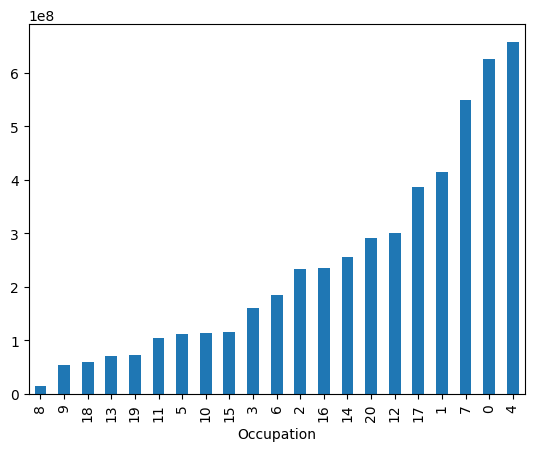

In [29]:
df.groupby("Occupation")["Purchase"].sum().sort_values().plot(kind="bar")

<Axes: xlabel='Occupation'>

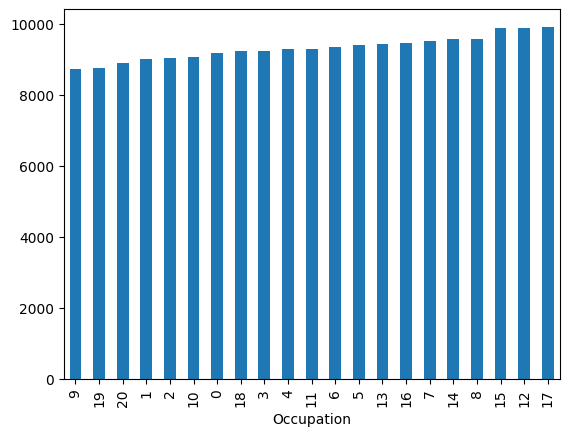

In [30]:
df.groupby("Occupation")["Purchase"].mean().sort_values().plot(kind="bar")

In [32]:
df.groupby("Occupation")["Purchase"].mean().sort_values()

Occupation
9     8714.335934
19    8754.249162
20    8881.099514
1     9017.703095
2     9025.938982
10    9052.836410
0     9186.946726
18    9233.671418
3     9238.077277
4     9279.026742
11    9299.467190
6     9336.378620
5     9388.848978
13    9424.449391
16    9457.133118
7     9502.175276
14    9568.536426
8     9576.508530
15    9866.239925
12    9883.052460
17    9906.378997
Name: Purchase, dtype: float64

<Axes: xlabel='Occupation', ylabel='count'>

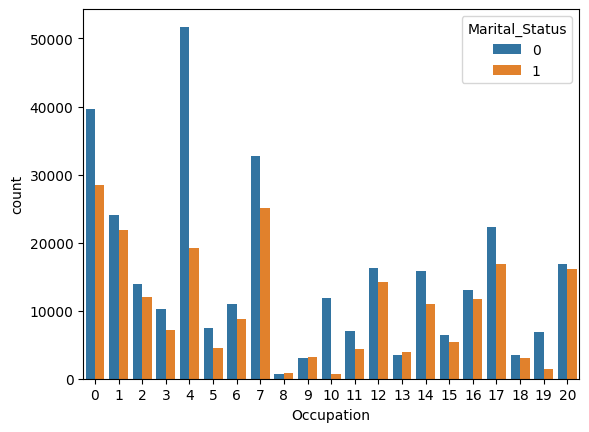

In [33]:
sns.countplot(x="Occupation",hue="Marital_Status",data=df)

<Axes: xlabel='Occupation', ylabel='count'>

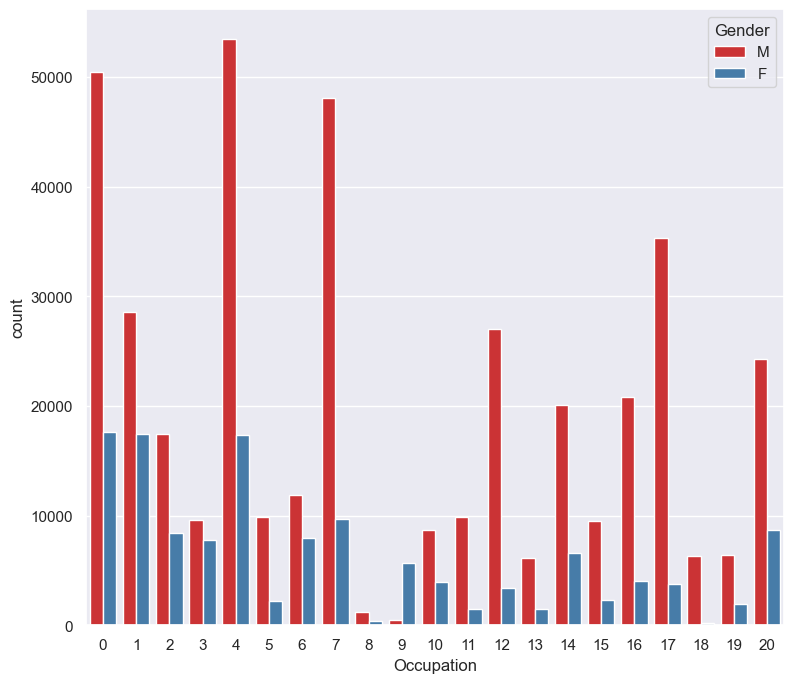

In [ ]:
#COUNT PLOT OF OCCUPATION WITH HUE GENDER:
sns.set(rc={"figure.figsize":(9,8)})
sns.countplot(x="Occupation",hue="Gender",palette="Set1",data=df)

In [35]:
df.groupby("Occupation")["Product_ID"].nunique()

Occupation
0     3243
1     3020
2     2892
3     2657
4     3174
5     2344
6     2724
7     3070
8     1026
9     1820
10    2110
11    2235
12    2664
13    1946
14    2680
15    2168
16    2863
17    2831
18    2047
19    2303
20    3147
Name: Product_ID, dtype: int64

<Axes: xlabel='Occupation'>

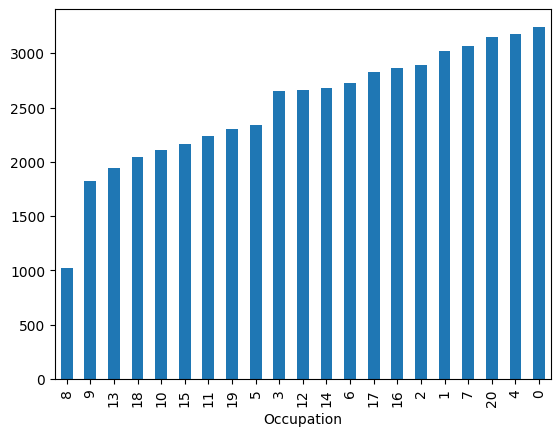

In [37]:
df.groupby("Occupation")["Product_ID"].nunique().sort_values().plot(kind="bar")

<Axes: xlabel='Product_Category_1'>

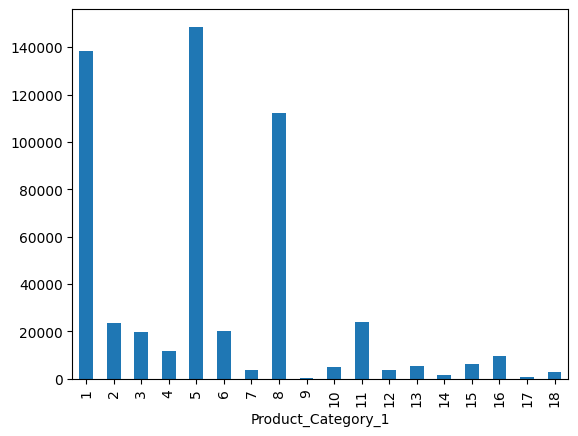

In [40]:
df.groupby("Product_Category_1").size().plot(kind="bar")

<Axes: xlabel='Product_Category_1'>

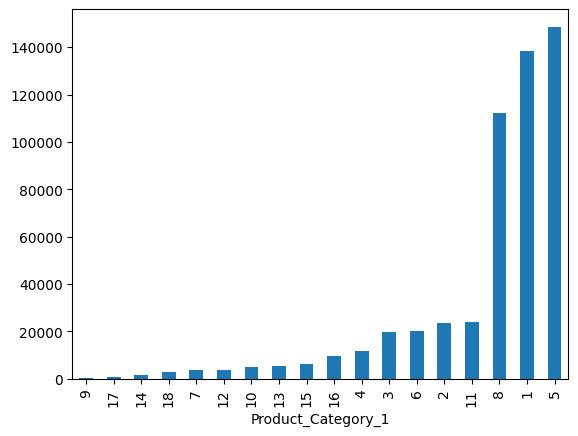

In [8]:
df.groupby("Product_Category_1").size().sort_values().plot(kind="bar")

<Axes: xlabel='Product_Category_1'>

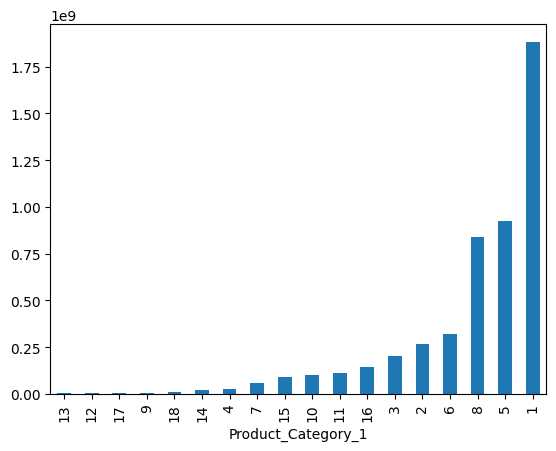

In [11]:
df.groupby("Product_Category_1")["Purchase"].sum().sort_values().plot(kind="bar")

<Axes: xlabel='Product_ID'>

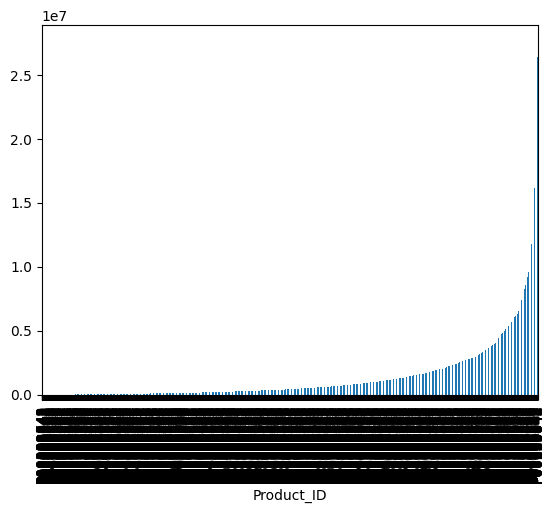

In [13]:
df.groupby("Product_ID")["Purchase"].sum().sort_values().plot(kind="bar")

In [19]:
lst=[]
for i in range(len(df)):
    lst.append(df["Gender"][i] +"_"+ str(df["Marital_Status"][i]))
df["Marital_gender"]=lst    

In [20]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Purchase,Marital_gender
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370,F_0
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200,F_0
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422,F_0
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057,F_0
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969,M_0


<Axes: xlabel='Marital_gender', ylabel='count'>

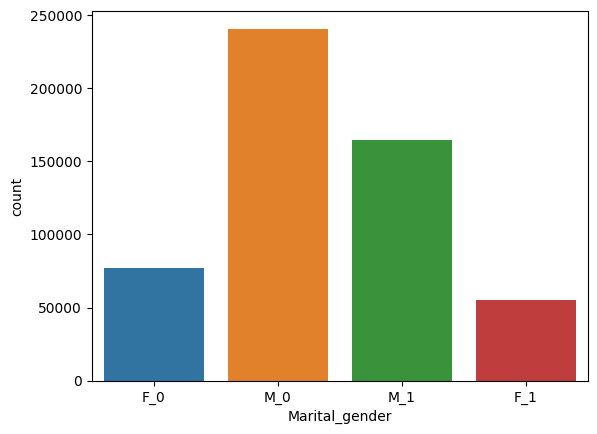

In [ ]:
sns.countplot(x="Marital_gender",hue="Marital_gender",data=df)

<Axes: xlabel='Age', ylabel='count'>

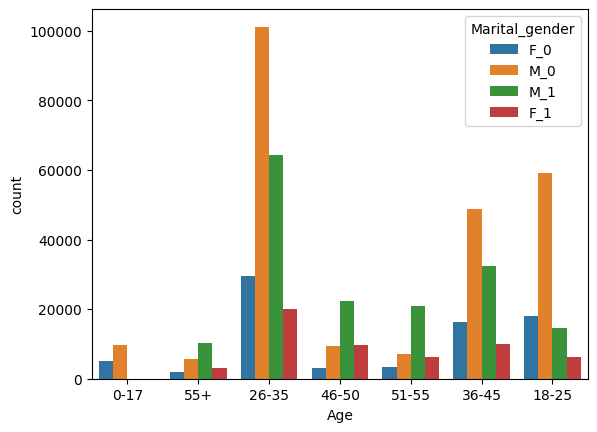

In [ ]:
#COUNT PLOT OF AGE WITH HUE MARITAL_GENDER:
sns.countplot(x="Age",hue="Marital_gender",data=df)

<Axes: xlabel='Product_Category_1', ylabel='count'>

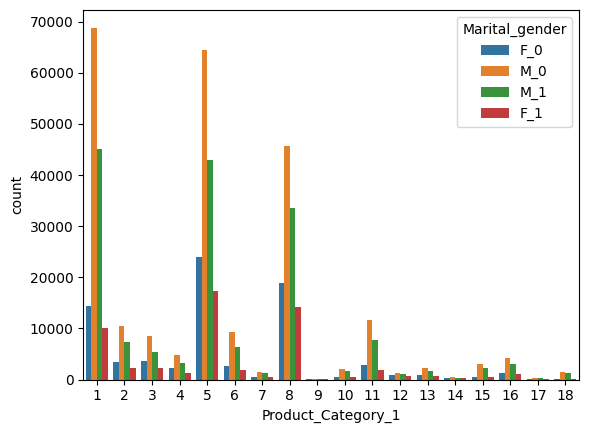

In [28]:
sns.countplot(x="Product_Category_1",hue="Marital_gender",data=df)

<Axes: xlabel='City_Category', ylabel='count'>

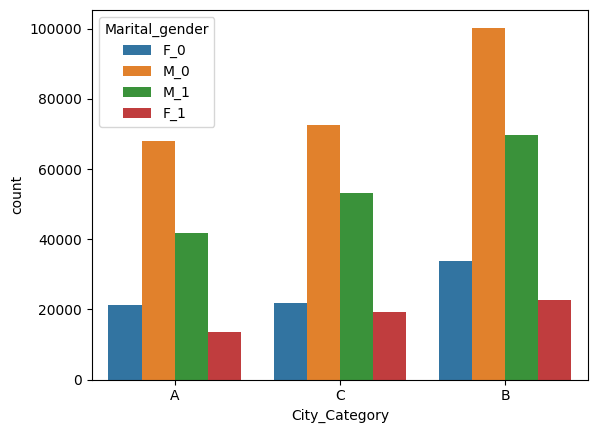

In [ ]:
#COUNTPLOT OF CITY CATEGORY WITH HUE MARITAL GENDER:
sns.countplot(x="City_Category",hue="Marital_gender",data=df)

CONCLUSION

  This project analyzes Black Friday sales data to identify customer purchasing behavior, popular product categories, and key factors influencing sales. The insights can help businesses make data-driven decisions, improve marketing strategies, and enhance customer satisfaction during major sales events.